# Load data & Preprocessing

In [10]:
# ============================================================
# PHẦN 1: DATA LOADING & PREPROCESSING
# HAM10000 Multimodal Skin Disease Classification
# ============================================================

import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

# ============================================================
# 1. ĐƯỜNG DẪN (Kaggle environment)
# ============================================================
METADATA_PATH = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv"
IMG_DIR_1     = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1"
IMG_DIR_2     = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2"

IMAGE_SIZE  = 224   # EfficientNetV2-S yêu cầu 224x224
BATCH_SIZE  = 32
NUM_WORKERS = 2
RANDOM_SEED = 42

# ============================================================
# 2. ĐỌC VÀ XỬ LÝ METADATA
# ============================================================
def load_metadata(metadata_path, img_dir_1, img_dir_2):
    df = pd.read_csv(metadata_path)

    # --- Tạo cột đường dẫn ảnh (gộp 2 thư mục part_1 và part_2) ---
    def find_image_path(image_id):
        for img_dir in [img_dir_1, img_dir_2]:
            path = os.path.join(img_dir, image_id + ".jpg")
            if os.path.exists(path):
                return path
        return None

    df["image_path"] = df["image_id"].apply(find_image_path)
    df = df[df["image_path"].notna()].reset_index(drop=True)
    print(f"Tổng ảnh tìm được: {len(df)}")

    # --- Xử lý giá trị thiếu ---
    df["age"] = df["age"].fillna(df["age"].median())

    # --- Encode nhãn bệnh (dx) ---
    label_encoder = LabelEncoder()
    df["label"] = label_encoder.fit_transform(df["dx"])
    print(f"7 nhãn bệnh: {list(label_encoder.classes_)}")

    # --- One-hot encode: sex ---
    df["sex_male"]    = (df["sex"] == "male").astype(float)
    df["sex_female"]  = (df["sex"] == "female").astype(float)
    df["sex_unknown"] = (~df["sex"].isin(["male", "female"])).astype(float)

    # --- One-hot encode: localization (vị trí trên cơ thể) ---
    loc_dummies = pd.get_dummies(df["localization"], prefix="loc").astype(float)
    df = pd.concat([df, loc_dummies], axis=1)

    # --- Normalize age về [0, 1] ---
    df["age_norm"] = (df["age"] - df["age"].min()) / (df["age"].max() - df["age"].min())

    # --- Tạo vector metadata ---
    loc_cols = [c for c in df.columns if c.startswith("loc_")]
    metadata_cols = ["age_norm", "sex_male", "sex_female", "sex_unknown"] + loc_cols
    print(f"Số chiều metadata: {len(metadata_cols)}")

    return df, label_encoder, metadata_cols


# ============================================================
# 3. TRAIN / VAL / TEST SPLIT (stratified)
# ============================================================
def split_data(df, random_seed=RANDOM_SEED):
    # Stratified split để giữ tỉ lệ class ở cả 3 tập
    train_df, temp_df = train_test_split(
        df, test_size=0.2, stratify=df["label"], random_state=random_seed
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, stratify=temp_df["label"], random_state=random_seed
    )
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


# ============================================================
# 4. AUGMENTATION & TRANSFORMS
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


# ============================================================
# 5. CUSTOM DATASET
# ============================================================
class HAM10000Dataset(Dataset):
    def __init__(self, df, metadata_cols, transform=None):
        self.df            = df
        self.metadata_cols = metadata_cols
        self.transform     = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # --- Ảnh ---
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # --- Metadata ---
        metadata = torch.tensor(
            row[self.metadata_cols].values.astype(np.float32),
            dtype=torch.float32
        )

        # --- Nhãn ---
        label = torch.tensor(row["label"], dtype=torch.long)

        return image, metadata, label


# ============================================================
# 6. WEIGHTED SAMPLER (xử lý class imbalance)
# ============================================================
def make_weighted_sampler(train_df):
    class_counts = train_df["label"].value_counts().sort_index().values
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[train_df["label"].values]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float32),
        num_samples=len(train_df),
        replacement=True
    )
    return sampler


# ============================================================
# 7. TẠO DATALOADERS
# ============================================================
def make_dataloaders(train_df, val_df, test_df, metadata_cols):
    train_dataset = HAM10000Dataset(train_df, metadata_cols, transform=train_transform)
    val_dataset   = HAM10000Dataset(val_df,   metadata_cols, transform=val_test_transform)
    test_dataset  = HAM10000Dataset(test_df,  metadata_cols, transform=val_test_transform)

    sampler = make_weighted_sampler(train_df)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                              sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                              shuffle=False,  num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                              shuffle=False,  num_workers=NUM_WORKERS, pin_memory=True)

    return train_loader, val_loader, test_loader


# ============================================================
# 8. CHẠY THỬ
# ============================================================
if __name__ == "__main__":
    # Load metadata
    df, label_encoder, metadata_cols = load_metadata(METADATA_PATH, IMG_DIR_1, IMG_DIR_2)

    # Kiểm tra phân bố class
    print("\nPhân bố nhãn bệnh:")
    print(df["dx"].value_counts())

    # Split
    train_df, val_df, test_df = split_data(df)

    # Tạo dataloaders
    train_loader, val_loader, test_loader = make_dataloaders(
        train_df, val_df, test_df, metadata_cols
    )

    # Kiểm tra 1 batch
    images, metadata, labels = next(iter(train_loader))
    print(f"\nBatch kiểm tra:")
    print(f"  images.shape   : {images.shape}")     # [32, 3, 224, 224]
    print(f"  metadata.shape : {metadata.shape}")   # [32, n_metadata_cols]
    print(f"  labels.shape   : {labels.shape}")     # [32]
    print(f"\nSố chiều metadata input cho MLP: {metadata.shape[1]}")
    print("\n✓ Phần 1 hoàn tất! Lưu metadata_cols và label_encoder để dùng ở phần sau.")

Tổng ảnh tìm được: 10015
7 nhãn bệnh: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Số chiều metadata: 19

Phân bố nhãn bệnh:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64
Train: 8012 | Val: 1001 | Test: 1002

Batch kiểm tra:
  images.shape   : torch.Size([32, 3, 224, 224])
  metadata.shape : torch.Size([32, 19])
  labels.shape   : torch.Size([32])

Số chiều metadata input cho MLP: 19

✓ Phần 1 hoàn tất! Lưu metadata_cols và label_encoder để dùng ở phần sau.


# Model

In [11]:
# ============================================================
# PHẦN 2: MODEL ARCHITECTURE
# Multimodal: EfficientNetV2-S (ảnh) + MLP (metadata) → Fusion → Classifier
# ============================================================

import torch
import torch.nn as nn
import torchvision.models as models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang dùng: {DEVICE}")

NUM_CLASSES      = 7    # 7 loại bệnh da
METADATA_DIM     = 19   # từ output Phần 1
IMAGE_EMBED_DIM  = 512  # output EfficientNetV2-S sau khi thay head
META_EMBED_DIM   = 128  # output MLP encoder
FUSION_DIM       = 256  # sau khi concat + FC


# ============================================================
# 1. NHÁNH ẢNH — EfficientNetV2-S (pretrained)
# ============================================================
class ImageEncoder(nn.Module):
    def __init__(self, embed_dim=IMAGE_EMBED_DIM, dropout=0.3):
        super().__init__()

        # Load pretrained EfficientNetV2-S
        backbone = models.efficientnet_v2_s(weights=models.EfficientNet_V2_S_Weights.DEFAULT)

        # Giữ toàn bộ feature extractor, thay classifier head
        self.features = backbone.features
        self.avgpool  = backbone.avgpool

        # Head mới: 1280 (output gốc của EfficientNetV2-S) → embed_dim
        self.head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(1280, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x = self.features(x)       # [B, 1280, 7, 7]
        x = self.avgpool(x)        # [B, 1280, 1, 1]
        x = torch.flatten(x, 1)   # [B, 1280]
        x = self.head(x)           # [B, 512]
        return x


# ============================================================
# 2. NHÁNH METADATA — MLP Encoder
# ============================================================
class MetadataEncoder(nn.Module):
    def __init__(self, input_dim=METADATA_DIM, embed_dim=META_EMBED_DIM, dropout=0.3):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),

            nn.Linear(64, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.encoder(x)   # [B, 128]


# ============================================================
# 3. FUSION + CLASSIFIER
# ============================================================
class MultimodalClassifier(nn.Module):
    def __init__(
        self,
        num_classes=NUM_CLASSES,
        metadata_dim=METADATA_DIM,
        image_embed_dim=IMAGE_EMBED_DIM,
        meta_embed_dim=META_EMBED_DIM,
        fusion_dim=FUSION_DIM,
        dropout=0.4,
    ):
        super().__init__()

        self.image_encoder    = ImageEncoder(embed_dim=image_embed_dim)
        self.metadata_encoder = MetadataEncoder(input_dim=metadata_dim, embed_dim=meta_embed_dim)

        # Concat: image_embed_dim + meta_embed_dim = 512 + 128 = 640
        concat_dim = image_embed_dim + meta_embed_dim

        self.fusion = nn.Sequential(
            nn.Linear(concat_dim, fusion_dim),
            nn.BatchNorm1d(fusion_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
        )

        self.classifier = nn.Linear(fusion_dim, num_classes)

    def forward(self, image, metadata):
        img_feat  = self.image_encoder(image)       # [B, 512]
        meta_feat = self.metadata_encoder(metadata) # [B, 128]

        fused = torch.cat([img_feat, meta_feat], dim=1)  # [B, 640]
        fused = self.fusion(fused)                        # [B, 256]
        out   = self.classifier(fused)                    # [B, 7]
        return out

    def get_image_features(self, image):
        """Dùng cho Grad-CAM ở Phần 4"""
        return self.image_encoder.features(image)


# ============================================================
# 4. KIỂM TRA MODEL
# ============================================================
if __name__ == "__main__":
    model = MultimodalClassifier().to(DEVICE)

    # Đếm số parameters
    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Tổng parameters    : {total_params:,}")
    print(f"Trainable params   : {trainable_params:,}")

    # Test forward pass với dummy input
    dummy_images   = torch.randn(4, 3, 224, 224).to(DEVICE)
    dummy_metadata = torch.randn(4, METADATA_DIM).to(DEVICE)

    with torch.no_grad():
        output = model(dummy_images, dummy_metadata)

    print(f"\nForward pass test:")
    print(f"  Input ảnh      : {dummy_images.shape}")
    print(f"  Input metadata : {dummy_metadata.shape}")
    print(f"  Output logits  : {output.shape}")   # [4, 7]
    print("\n✓ Phần 2 hoàn tất! Model sẵn sàng để train.")

Đang dùng: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 204MB/s] 


Tổng parameters    : 21,010,775
Trainable params   : 21,010,775

Forward pass test:
  Input ảnh      : torch.Size([4, 3, 224, 224])
  Input metadata : torch.Size([4, 19])
  Output logits  : torch.Size([4, 7])

✓ Phần 2 hoàn tất! Model sẵn sàng để train.


# Train

In [12]:
# ============================================================
# PHẦN 3: TRAINING LOOP
# Focal Loss + AdamW + CosineAnnealingLR + Early Stopping
# ============================================================

import time
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import balanced_accuracy_score

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 50
LR         = 3e-4
LR_MIN     = 1e-6
PATIENCE   = 7       # Early stopping sau 7 epoch không cải thiện
SAVE_PATH  = "/kaggle/working/best_model.pth"


# ============================================================
# 1. FOCAL LOSS (xử lý class imbalance tốt hơn CrossEntropy)
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight  # class weights để tăng cường thêm

    def forward(self, inputs, targets):
        ce_loss = nn.functional.cross_entropy(inputs, targets,
                                              weight=self.weight, reduction="none")
        pt      = torch.exp(-ce_loss)
        loss    = ((1 - pt) ** self.gamma) * ce_loss
        return loss.mean()


def compute_class_weights(train_df, num_classes, device):
    """Tính class weights tỉ lệ nghịch với tần suất"""
    counts  = np.bincount(train_df["label"].values, minlength=num_classes)
    weights = 1.0 / (counts + 1e-6)
    weights = weights / weights.sum() * num_classes  # normalize
    return torch.tensor(weights, dtype=torch.float32).to(device)


# ============================================================
# 2. TRAIN 1 EPOCH
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels      = [], []

    for images, metadata, labels in loader:
        images   = images.to(DEVICE)
        metadata = metadata.to(DEVICE)
        labels   = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images, metadata)
        loss    = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping tránh exploding gradient
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss     = total_loss / total
    accuracy     = correct / total
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy, balanced_acc


# ============================================================
# 3. VALIDATE
# ============================================================
@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels      = [], []

    for images, metadata, labels in loader:
        images   = images.to(DEVICE)
        metadata = metadata.to(DEVICE)
        labels   = labels.to(DEVICE)

        outputs     = model(images, metadata)
        loss        = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss     = total_loss / total
    accuracy     = correct / total
    balanced_acc = balanced_accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy, balanced_acc


# ============================================================
# 4. FULL TRAINING LOOP
# ============================================================
def train(model, train_loader, val_loader, train_df):
    # Class weights cho Focal Loss
    #class_weights = compute_class_weights(train_df, num_classes=7, device=DEVICE)
    criterion     = FocalLoss(gamma=2.0, weight=None)

    # Optimizer: weight decay chỉ áp dụng cho weight, không áp cho bias/BN
    param_groups = [
        {"params": model.image_encoder.features.parameters(), "lr": LR * 0.1},
        {"params": model.image_encoder.head.parameters(),     "lr": LR},
        {"params": model.metadata_encoder.parameters(),       "lr": LR},
        {"params": model.fusion.parameters(),                 "lr": LR},
        {"params": model.classifier.parameters(),             "lr": LR},
    ]
    optimizer = optim.AdamW(param_groups, weight_decay=1e-4)

    # Scheduler: cosine annealing
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NUM_EPOCHS, eta_min=LR_MIN
    )

    # Tracking
    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  [],
               "train_bacc": [], "val_bacc": []}

    best_val_bacc  = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_count = 0

    print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val Loss':>8} | "
          f"{'Train BAcc':>10} | {'Val BAcc':>8} | {'Time':>6}")
    print("-" * 65)

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()

        train_loss, train_acc, train_bacc = train_one_epoch(
            model, train_loader, optimizer, criterion
        )
        val_loss, val_acc, val_bacc = validate(model, val_loader, criterion)
        scheduler.step()

        # Lưu history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_bacc"].append(train_bacc)
        history["val_bacc"].append(val_bacc)

        elapsed = time.time() - t0
        print(f"{epoch:>5} | {train_loss:>10.4f} | {val_loss:>8.4f} | "
              f"{train_bacc:>10.4f} | {val_bacc:>8.4f} | {elapsed:>5.1f}s")

        # Early stopping dựa trên balanced accuracy (quan trọng hơn accuracy thường)
        if val_bacc > best_val_bacc:
            best_val_bacc  = val_bacc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save({
                "epoch":      epoch,
                "model_state_dict": best_model_wts,
                "val_bacc":   best_val_bacc,
                "val_acc":    val_acc,
            }, SAVE_PATH)
            patience_count = 0
            print(f"         ✓ Best model saved (val_bacc={best_val_bacc:.4f})")
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f"\nEarly stopping tại epoch {epoch} (không cải thiện sau {PATIENCE} epoch)")
                break

    # Load lại best model
    model.load_state_dict(best_model_wts)
    print(f"\n✓ Training hoàn tất! Best val balanced accuracy: {best_val_bacc:.4f}")
    return model, history


# ============================================================
# 5. CHẠY TRAINING
# ============================================================
if __name__ == "__main__":
    # Giả sử model, train_loader, val_loader, train_df
    # đã được tạo từ Phần 1 và Phần 2
    print("Bắt đầu training...")
    print(f"Device : {DEVICE}")
    print(f"Epochs : {NUM_EPOCHS}")
    print(f"LR     : {LR} (backbone x0.1 = {LR*0.1})")
    print(f"Patience: {PATIENCE} epochs\n")

    model, history = train(model, train_loader, val_loader, train_df)

Bắt đầu training...
Device : cuda
Epochs : 50
LR     : 0.0003 (backbone x0.1 = 2.9999999999999997e-05)
Patience: 7 epochs

Epoch | Train Loss | Val Loss | Train BAcc | Val BAcc |   Time
-----------------------------------------------------------------
    1 |     0.7438 |   0.4842 |     0.5576 |   0.7420 |  99.6s
         ✓ Best model saved (val_bacc=0.7420)
    2 |     0.3880 |   0.3451 |     0.7296 |   0.8123 |  98.4s
         ✓ Best model saved (val_bacc=0.8123)
    3 |     0.2829 |   0.2557 |     0.7931 |   0.8162 |  98.3s
         ✓ Best model saved (val_bacc=0.8162)
    4 |     0.2230 |   0.2677 |     0.8275 |   0.8012 |  98.8s
    5 |     0.1755 |   0.2258 |     0.8591 |   0.8465 |  98.6s
         ✓ Best model saved (val_bacc=0.8465)
    6 |     0.1486 |   0.2136 |     0.8727 |   0.8076 |  98.8s
    7 |     0.1272 |   0.1899 |     0.8895 |   0.8559 |  98.7s
         ✓ Best model saved (val_bacc=0.8559)
    8 |     0.1174 |   0.1816 |     0.8972 |   0.8237 |  98.6s
    9 |     0.

# Evaluation

Loaded best model (val_bacc=0.8715)

TEST SET RESULTS
Balanced Accuracy : 0.8528 (85.28%)
Macro AUC-ROC     : 0.9819 (98.19%)

Classification Report:
              precision    recall  f1-score   support

       akiec     0.6757    0.7812    0.7246        32
         bcc     0.7619    0.9231    0.8348        52
         bkl     0.7768    0.7909    0.7838       110
          df     1.0000    0.9091    0.9524        11
         mel     0.6504    0.7143    0.6809       112
          nv     0.9612    0.9225    0.9414       671
        vasc     1.0000    0.9286    0.9630        14

    accuracy                         0.8802      1002
   macro avg     0.8323    0.8528    0.8401      1002
weighted avg     0.8877    0.8802    0.8830      1002


Mel Threshold Tuning:
 Threshold | Mel Recall | NV Recall |  Bal Acc
------------------------------------------------
      0.20 |     0.8839 |    0.8256 |   0.8567
      0.25 |     0.8393 |    0.8539 |   0.8570
      0.30 |     0.8214 |    0.8763 |   

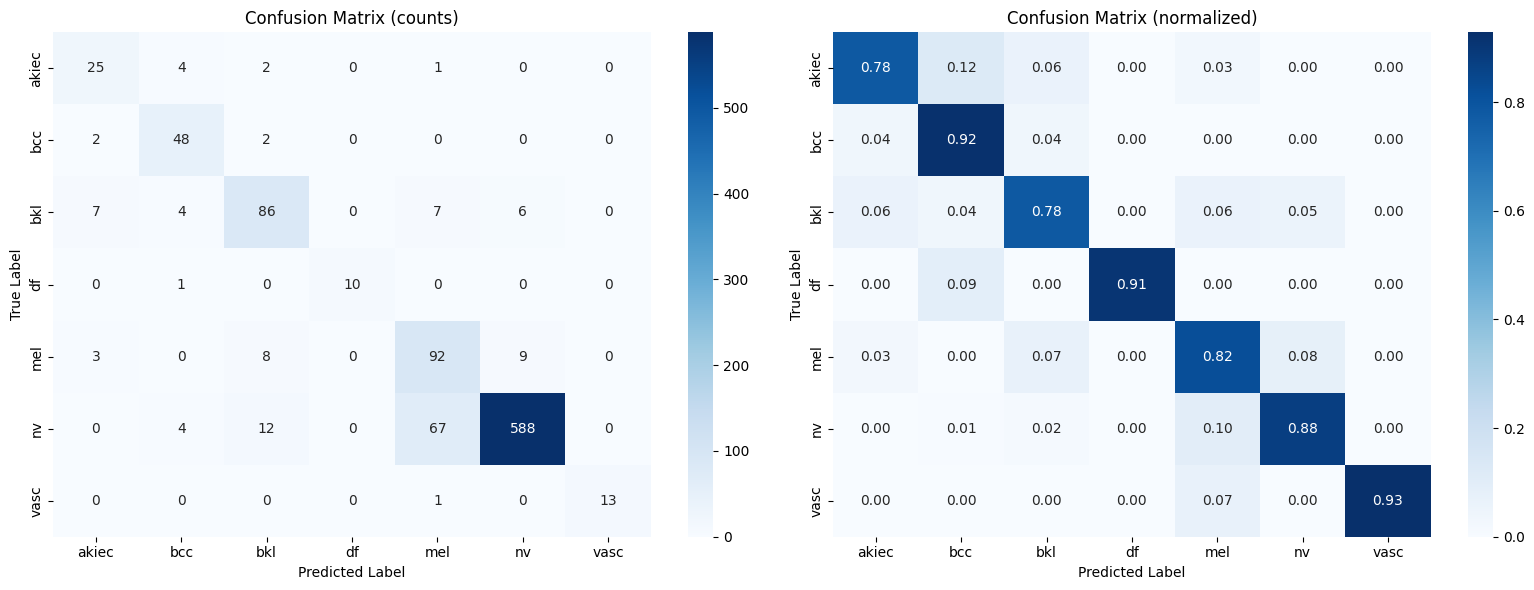

✓ Confusion matrix saved!

Generating Grad-CAM visualizations...


/tmp/ipykernel_58/2719302540.py:171: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  samples = test_df.groupby("label").apply(


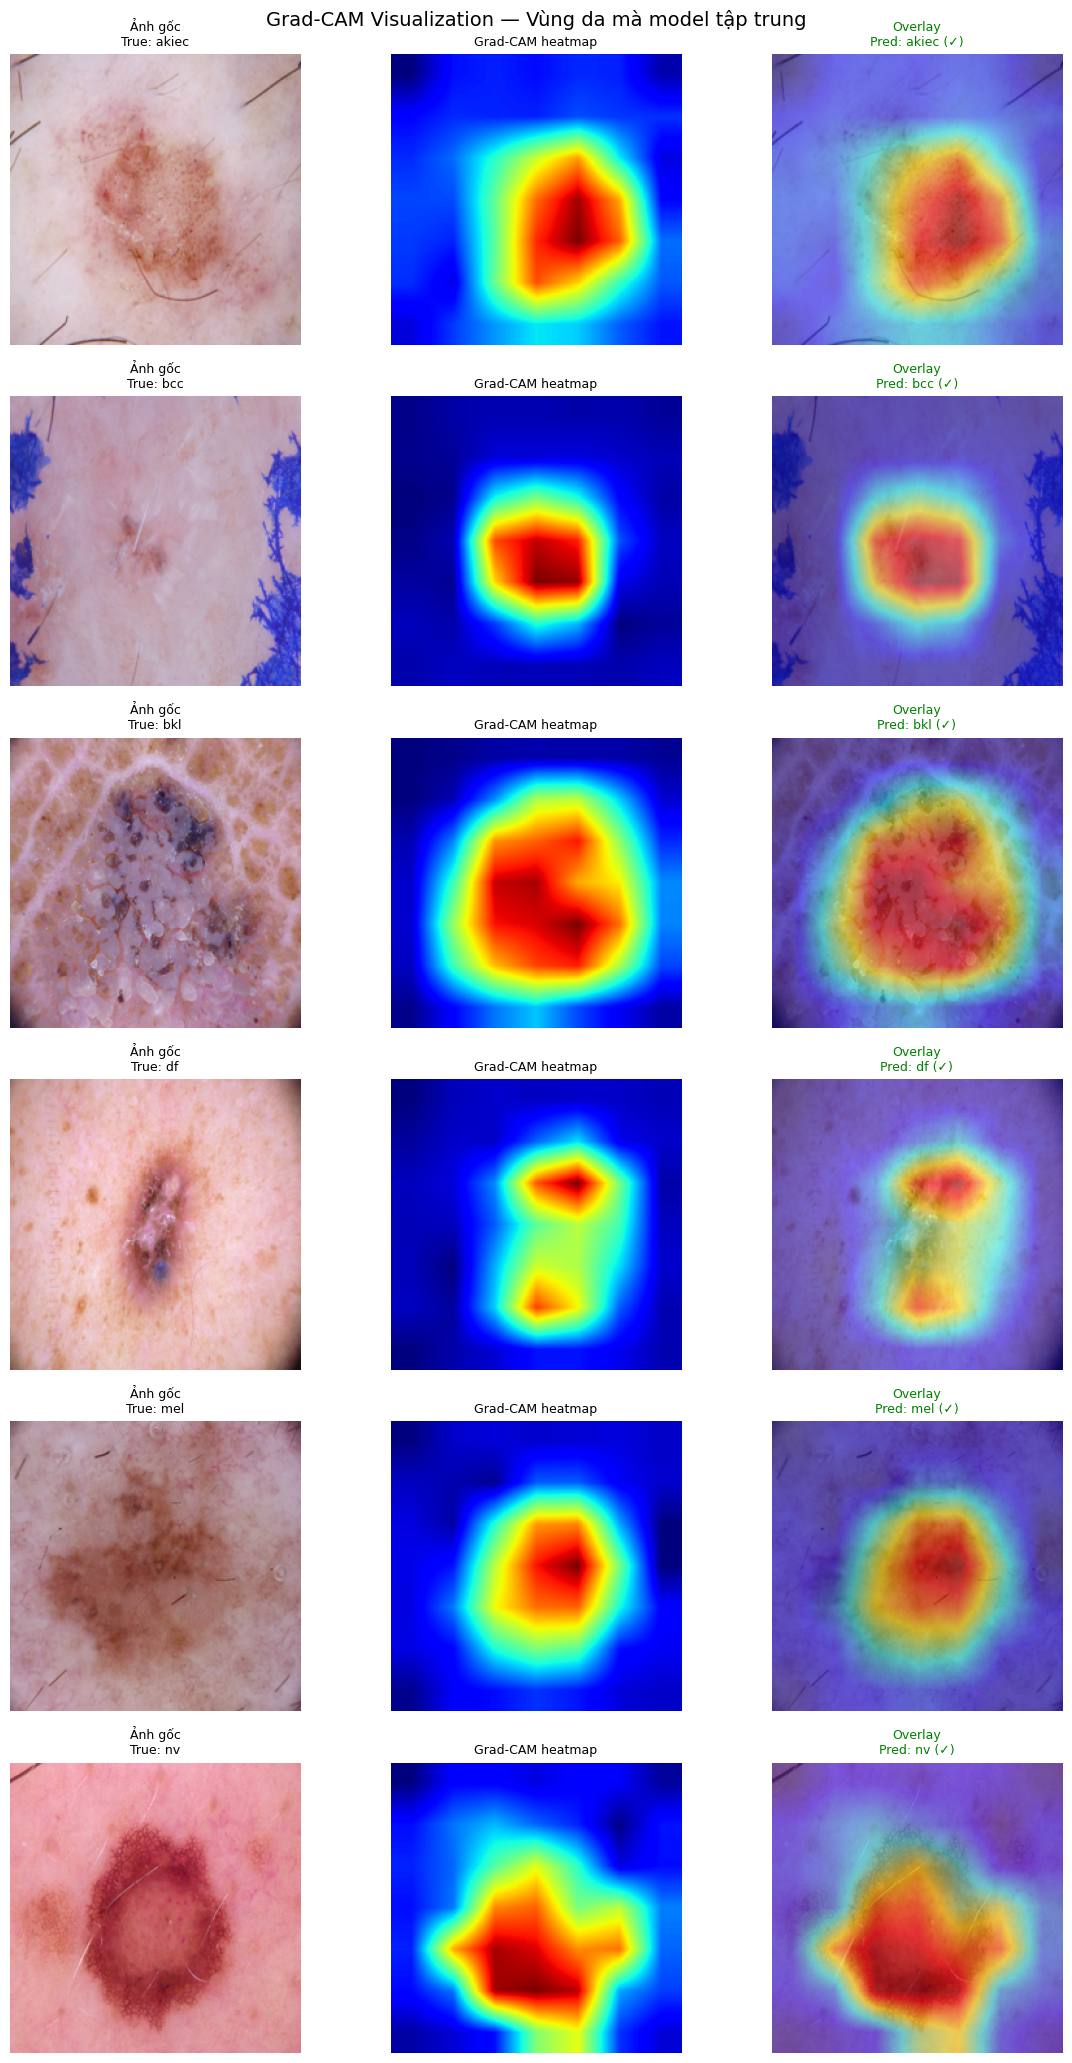

✓ Grad-CAM saved!

SUMMARY
Balanced Accuracy : 85.28%
Macro AUC-ROC     : 98.19%
Files saved:
  /kaggle/working/confusion_matrix.png
  /kaggle/working/gradcam_visualization.png


In [14]:
# ============================================================
# PHẦN 4: EVALUATION + GRAD-CAM
# Metrics đầy đủ trên test set + visualize vùng da bất thường
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, balanced_accuracy_score
)
import seaborn as sns
import cv2
from PIL import Image

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


# ============================================================
# 1. EVALUATION TRÊN TEST SET
# ============================================================
@torch.no_grad()
def evaluate_test(model, test_loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for images, metadata, labels in test_loader:
        images   = images.to(DEVICE)
        metadata = metadata.to(DEVICE)
        outputs  = model(images, metadata)
        probs    = F.softmax(outputs, dim=1)

        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    # Metrics
    bacc = balanced_accuracy_score(all_labels, all_preds)
    auc  = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")

    print("=" * 60)
    print(f"TEST SET RESULTS")
    print("=" * 60)
    print(f"Balanced Accuracy : {bacc:.4f} ({bacc*100:.2f}%)")
    print(f"Macro AUC-ROC     : {auc:.4f} ({auc*100:.2f}%)")
    print()
    print("Classification Report:")
    print(classification_report(all_labels, all_preds,
                                target_names=CLASS_NAMES, digits=4))

    return all_preds, all_labels, all_probs, bacc, auc




# ============================================================
# 2. MEL THRESHOLD TUNING
# Hạ ngưỡng predict mel để giảm bỏ sót ung thư (mel→nv)
# ============================================================
MEL_IDX = CLASS_NAMES.index('mel')  # = 4

def apply_mel_threshold(all_probs, mel_threshold=0.35):
    preds = np.argmax(all_probs, axis=1).copy()
    preds[all_probs[:, MEL_IDX] >= mel_threshold] = MEL_IDX
    return preds


def tune_mel_threshold(all_labels, all_probs, thresholds=None):
    from sklearn.metrics import recall_score
    if thresholds is None:
        thresholds = np.arange(0.20, 0.55, 0.05)

    NV_IDX = CLASS_NAMES.index('nv')  # = 5
    print(f"{'Threshold':>10} | {'Mel Recall':>10} | {'NV Recall':>9} | {'Bal Acc':>8}")
    print("-" * 48)
    for t in thresholds:
        preds      = apply_mel_threshold(all_probs, mel_threshold=t)
        mel_recall = recall_score(all_labels, preds, labels=[MEL_IDX], average=None)[0]
        nv_recall  = recall_score(all_labels, preds, labels=[NV_IDX],  average=None)[0]
        bacc       = balanced_accuracy_score(all_labels, preds)
        print(f"{t:>10.2f} | {mel_recall:>10.4f} | {nv_recall:>9.4f} | {bacc:>8.4f}")

# ============================================================
# 3. CONFUSION MATRIX
# ============================================================
def plot_confusion_matrix(all_labels, all_preds):
    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalize theo row

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
    axes[0].set_title("Confusion Matrix (counts)")
    axes[0].set_ylabel("True Label")
    axes[0].set_xlabel("Predicted Label")

    # Normalized
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
    axes[1].set_title("Confusion Matrix (normalized)")
    axes[1].set_ylabel("True Label")
    axes[1].set_xlabel("Predicted Label")

    plt.tight_layout()
    plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Confusion matrix saved!")


# ============================================================
# 4. GRAD-CAM
# ============================================================
class GradCAM:
    def __init__(self, model):
        self.model      = model
        self.gradients  = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        # Hook vào layer cuối của EfficientNetV2-S features
        target_layer = self.model.image_encoder.features[-1]

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def generate(self, image, metadata, class_idx=None):
        self.model.eval()
        image    = image.to(DEVICE)
        metadata = metadata.to(DEVICE)

        output = self.model(image, metadata)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        # Tính CAM
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # [1, C, 1, 1]
        cam     = (weights * self.activations).sum(dim=1).squeeze()  # [H, W]
        cam     = F.relu(cam)
        cam     = cam - cam.min()
        cam     = cam / (cam.max() + 1e-8)

        return cam.cpu().numpy(), class_idx


def visualize_gradcam(model, test_df, metadata_cols, n_samples=6):
    gradcam = GradCAM(model)
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    # Lấy mẫu đa dạng từ các class khác nhau
    samples = test_df.groupby("label").apply(
        lambda x: x.sample(1, random_state=42)
    ).reset_index(drop=True).head(n_samples)

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, n_samples * 3.5))
    fig.suptitle("Grad-CAM Visualization — Vùng da mà model tập trung", fontsize=14)

    for i, (_, row) in enumerate(samples.iterrows()):
        # Load ảnh gốc
        orig_img = Image.open(row["image_path"]).convert("RGB")
        orig_img = orig_img.resize((224, 224))
        orig_arr = np.array(orig_img) / 255.0

        # Prepare tensors
        img_tensor  = val_test_transform(orig_img).unsqueeze(0)
        meta_tensor = torch.tensor(
            row[metadata_cols].values.astype(np.float32)
        ).unsqueeze(0)

        # Generate CAM
        cam, pred_idx = gradcam.generate(img_tensor, meta_tensor)
        true_idx      = int(row["label"])

        # Resize CAM về 224x224
        cam_resized = cv2.resize(cam, (224, 224))
        heatmap     = cv2.applyColorMap(
            (cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET
        )
        heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
        overlay     = 0.5 * orig_arr + 0.5 * heatmap
        overlay     = np.clip(overlay, 0, 1)

        # Plot
        correct = pred_idx == true_idx
        color   = "green" if correct else "red"

        axes[i, 0].imshow(orig_arr)
        axes[i, 0].set_title(f"Ảnh gốc\nTrue: {CLASS_NAMES[true_idx]}", fontsize=9)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(cam_resized, cmap="jet")
        axes[i, 1].set_title("Grad-CAM heatmap", fontsize=9)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title(
            f"Overlay\nPred: {CLASS_NAMES[pred_idx]} ({'✓' if correct else '✗'})",
            fontsize=9, color=color
        )
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.savefig("/kaggle/working/gradcam_visualization.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Grad-CAM saved!")


# ============================================================
# 5. CHẠY TOÀN BỘ EVALUATION
# ============================================================
if __name__ == "__main__":
    # Load best model
    checkpoint = torch.load(SAVE_PATH, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded best model (val_bacc={checkpoint['val_bacc']:.4f})\n")

    # 1. Metrics trên test set (dùng argmax gốc)
    all_preds, all_labels, all_probs, bacc, auc = evaluate_test(model, test_loader)

    # 2. Mel threshold tuning — chọn threshold tốt nhất từ bảng
    print("\nMel Threshold Tuning:")
    tune_mel_threshold(all_labels, all_probs)

    MEL_THRESHOLD = 0.30  # ← điều chỉnh sau khi xem bảng trên
    all_preds_tuned = apply_mel_threshold(all_probs, mel_threshold=MEL_THRESHOLD)
    print(f"\n→ Áp dụng threshold={MEL_THRESHOLD}")

    # 3. Confusion matrix với preds đã tune
    plot_confusion_matrix(all_labels, all_preds_tuned)

    # 4. Grad-CAM visualization
    print("\nGenerating Grad-CAM visualizations...")
    visualize_gradcam(model, test_df, metadata_cols, n_samples=6)

    print("\n" + "=" * 60)
    print("SUMMARY")
    print("=" * 60)
    print(f"Balanced Accuracy : {bacc*100:.2f}%")
    print(f"Macro AUC-ROC     : {auc*100:.2f}%")
    print(f"Files saved:")
    print(f"  /kaggle/working/confusion_matrix.png")
    print(f"  /kaggle/working/gradcam_visualization.png")